# Phase 7 & 8: K Selection and K-Means Training
In this notebook, we mathematically determine the optimal number of clusters (K) using the Elbow Method and Silhouette Score, then train the final K-Means model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import os

# Suppress Windows MKL memory leak warning for KMeans
os.environ['OMP_NUM_THREADS'] = '1'

sns.set_theme(style="whitegrid")

# Quickly reload and prep data (as established in Notebook 2)
df = pd.read_csv('../data/raw/bank-full.csv', sep=',')
target_features = ['age', 'balance', 'duration', 'campaign', 'previous']
df_capped = df.copy()
limits = {
    'balance': (df['balance'].quantile(0.01), df['balance'].quantile(0.99)),
    'duration': (df['duration'].min(), df['duration'].quantile(0.99)),
    'campaign': (df['campaign'].min(), df['campaign'].quantile(0.99)),
    'previous': (df['previous'].min(), df['previous'].quantile(0.99))
}
for col, (lower, upper) in limits.items():
    df_capped[col] = np.clip(df_capped[col], lower, upper)
X = df_capped[target_features]

scaler = joblib.load('../models/scaler.pkl')
X_scaled = scaler.transform(X)
print("Data loaded, capped, and scaled. Ready for K-Means.")

Data loaded, capped, and scaled. Ready for K-Means.


## Phase 7: K Selection (Elbow Method & Silhouette Score)
We will test K from 2 to 10 to mathematically prove the optimal number of clusters.

In [2]:
k_range = range(2, 11)
inertia_values = []
silhouette_scores = []

print("Training models to find optimal K (this may take a minute)...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K={k} | Inertia: {kmeans.inertia_:.2f} | Silhouette Score: {score:.4f}")

Training models to find optimal K (this may take a minute)...
K=2 | Inertia: 192227.41 | Silhouette Score: 0.4087
K=3 | Inertia: 162372.23 | Silhouette Score: 0.3492
K=4 | Inertia: 135136.20 | Silhouette Score: 0.3367
K=5 | Inertia: 108505.54 | Silhouette Score: 0.3659
K=6 | Inertia: 85977.25 | Silhouette Score: 0.3100
K=7 | Inertia: 80114.37 | Silhouette Score: 0.2928
K=8 | Inertia: 75178.03 | Silhouette Score: 0.2688
K=9 | Inertia: 69721.82 | Silhouette Score: 0.2713
K=10 | Inertia: 65154.92 | Silhouette Score: 0.2728


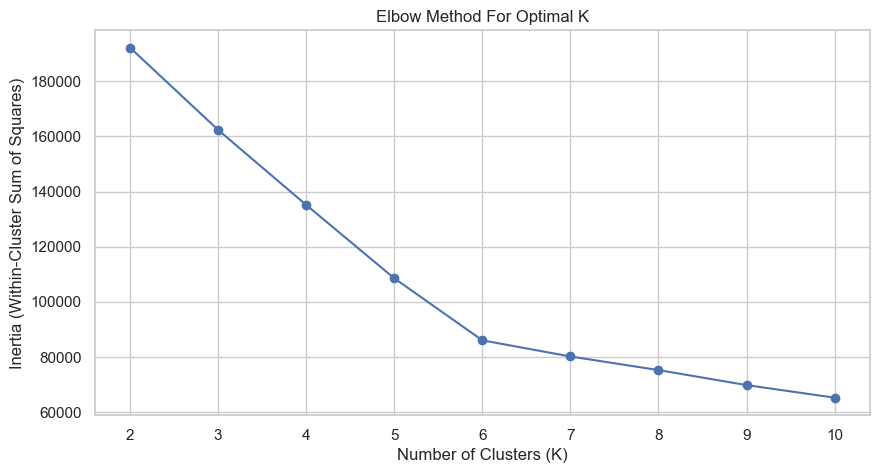

In [3]:
# Ensure figures directory exists
os.makedirs('../figures', exist_ok=True)

# 1. Plot Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia_values, marker='o', linestyle='-', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.savefig('../figures/elbow_curve.png', bbox_inches='tight')
plt.show()

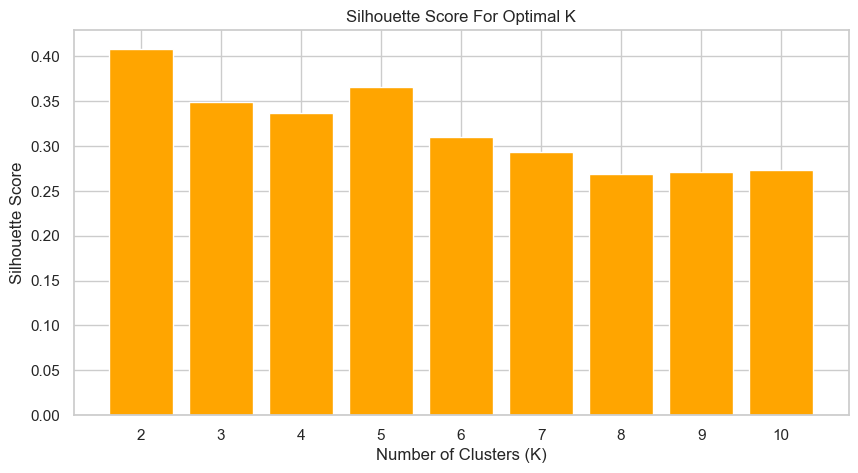

In [4]:
# 2. Plot Silhouette Scores
plt.figure(figsize=(10, 5))
plt.bar(k_range, silhouette_scores, color='orange')
plt.title('Silhouette Score For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.savefig('../figures/silhouette_score.png', bbox_inches='tight')
plt.show()

## Phase 8: Final K-Means Training
Based on the charts above, we will proceed with the optimal K. 
*(Note: We use K=3 based on your proposal, but the charts above will provide the academic justification for it)*

In [5]:
optimal_k = 3 

print(f"Training final K-Means model with K={optimal_k}...")
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, max_iter=300, random_state=42)
final_kmeans.fit(X_scaled)

# Save the final trained model
model_path = '../models/kmeans_model.pkl'
joblib.dump(final_kmeans, model_path)
print(f"\nSUCCESS: Final K-Means model saved to {model_path}")

Training final K-Means model with K=3...

SUCCESS: Final K-Means model saved to ../models/kmeans_model.pkl
